# Fine-Tuning a Bengali Embedding Model for Specialized Retrieval

<img src="https://static.prothomalo.com/prothomalo-bangla/2021-02/87271e1c-59f7-4171-8514-93b5d590e8a0/21022021_Boimela_1_Online.jpg" width=600>

## Abstract
Embedding models are the cornerstone of modern Retrieval Augmented Generation (RAG) systems, enabling language models to retrieve relevant context from vast knowledge bases. While multilingual models offer broad utility, they often lack the nuanced understanding required for optimal performance in a specific language or domain. This is particularly true for languages like Bengali. This notebook details a reproducible methodology for enhancing a general-purpose Bengali sentence transformer for the task of information retrieval. We demonstrate a significant performance uplift by fine-tuning the `shihab17/bangla-sentence-transformer` model on a native Bengali Question-Answering dataset. We employ Matryoshka Representation Learning (MRL) to create efficient, variable-dimension embeddings and conduct a comprehensive evaluation using standard IR metrics. The resulting model shows substantial improvements across all metrics, providing the Bengali NLP community with a powerful, specialized tool for semantic search and RAG applications.

### Objectives & Workflow:

1. **Dataset Preparation**: Process a Bengali Question-Answering dataset to create positive (query, context) pairs suitable for training.
2. **Base Model Evaluation**: Establish a performance baseline for the pre-trained `shihab17/bangla-sentence-transformer` on our specific retrieval task.
3. **Fine-Tuning with Matryoshka Representation Learning**: Fine-tune the model using `MultipleNegativesRankingLoss` and `MatryoshkaLoss` to learn semantically rich embeddings at multiple dimensions (768, 512, 256, 128, 64).
4. **Comprehensive Evaluation**: Rigorously evaluate the fine-tuned model against the baseline using metrics like NDCG@10, MRR@10, MAP@100, and Accuracy@k.
5. **Results Analysis & Visualization**: Present a comparative analysis of the results through tables and plots to visually demonstrate the performance gains.
6. **Publishing & Usage**: Publish the fine-tuned model to the Hugging Face Hub and provide a clear example of its usage.

---
## 1. Environment Setup and Dependencies

In [1]:
%%capture
!pip install --upgrade sentence-transformers datasets transformers torch tensorboard pandas seaborn matplotlib

In [11]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

from sentence_transformers import SentenceTransformer, SentenceTransformerModelCardData, SentenceTransformerTrainingArguments, SentenceTransformerTrainer
from sentence_transformers.evaluation import InformationRetrievalEvaluator, SequentialEvaluator
from sentence_transformers.util import cos_sim
from sentence_transformers.losses import MatryoshkaLoss, MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers

from datasets import Dataset, concatenate_datasets, load_dataset
from huggingface_hub import login
from google.colab import userdata

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
print("Using Device: ", device)

Using Device:  cuda


**Login to Hugging Face**

This is required for pushing our fine-tuned model to the Hugging Face Hub.

In [4]:
login(token=userdata.get('HF_TOKEN'), add_to_git_credential=True)

---
## 2. Dataset Preparation

For fine-tuning a retrieval model, we need a dataset of `(query, positive_passage)` pairs. The `sartajekram/BanglaRQA` dataset is perfectly suited for this, as it contains questions (`question_text`) and their corresponding contexts (`context`) from which the answer can be derived.

Our preparation steps are:
1. Load the `sartajekram/BanglaRQA` dataset.
2. Filter for only **answerable** questions (`is_answerable == 1`) to ensure high-quality positive pairs.
3. Rename `question_text` to `anchor` and `context` to `positive` to match our training terminology.
4. Create a unique `id` for each pair, which is required for the evaluator.
5. Use the `passage_id` column to group questions related to the same context, which is crucial for building the `relevant_docs` mapping for evaluation.
6. Shuffle and split the data into a 90/10 train/test set.

In [6]:
!git lfs install

Git LFS initialized.


In [7]:
!git clone https://huggingface.co/datasets/sartajekram/BanglaRQA

Cloning into 'BanglaRQA'...
remote: Enumerating objects: 77, done.
remote: Total 77 (delta 0), reused 0 (delta 0), pack-reused 77 (from 1)
Unpacking objects: 100% (77/77), 1022.79 KiB | 4.17 MiB/s, done.


In [12]:
# Step 2: Define the parsing function
def load_and_parse_banglarqa(filepath):
    """Parses the nested BanglaRQA JSON file into a flat list of dictionaries."""
    with open(filepath, 'r', encoding='utf-8') as f:
        data = json.load(f)

    examples = []
    for article in data['data']:
        passage_id = article['passage_id']
        context = article['context']
        for qa in article['qas']:
            example = {
                'passage_id': passage_id,
                'context': context,
                'question_id': qa['question_id'],
                'question_text': qa['question_text'],
                'is_answerable': qa['is_answerable']
            }
            examples.append(example)
    return examples

# Step 3: Load data from local files
train_data = load_and_parse_banglarqa('BanglaRQA/Train.json')
validation_data = load_and_parse_banglarqa('BanglaRQA/Validation.json')
test_data = load_and_parse_banglarqa('BanglaRQA/Test.json')

# Combine train and validation sets for a larger training pool}
full_train_data = train_data + validation_data

# Step 4: Convert to datasets.Dataset objects
train_ds = Dataset.from_list(full_train_data)
test_ds = Dataset.from_list(test_data)

print(f"Raw train+validation examples: {len(train_ds)}")
print(f"Raw test examples: {len(test_ds)}")

Raw train+validation examples: 13396
Raw test examples: 1493


In [13]:
# Step 5: Filter for answerable questions and clean up datasets
print("Processing datasets...")

# Process Training Set
train_dataset = train_ds.filter(lambda example: example["is_answerable"] == "1")
train_dataset = train_dataset.rename_column("question_text", "anchor")
train_dataset = train_dataset.rename_column("context", "positive")
train_dataset = train_dataset.remove_columns([col for col in train_dataset.column_names if col not in ['anchor', 'positive', 'passage_id']])
train_dataset = train_dataset.add_column("id", range(len(train_dataset)))

# Process Test Set
test_dataset = test_ds.filter(lambda example: example["is_answerable"] == "1")
test_dataset = test_dataset.rename_column("question_text", "anchor")
test_dataset = test_dataset.rename_column("context", "positive")
test_dataset = test_dataset.remove_columns([col for col in test_dataset.column_names if col not in ['anchor', 'positive', 'passage_id']])
test_dataset = test_dataset.add_column("id", range(len(train_dataset), len(train_dataset) + len(test_dataset)))

print(f"\nFiltered Training set size: {len(train_dataset)}")
print(f"Filtered Test set size: {len(test_dataset)}")
print(f"\nExample from processed training set:\n{train_dataset[0]}")

# Step 7: Save the processed splits to disk for easy re-use
train_dataset.to_json("train_dataset_bn.json", orient="records", force_ascii=False)
test_dataset.to_json("test_dataset_bn.json", orient="records", force_ascii=False)

Processing datasets...


Filter:   0%|          | 0/13396 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/10134 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1493 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1124 [00:00<?, ? examples/s]


Filtered Training set size: 10134
Filtered Test set size: 1124

Example from processed training set:
{'passage_id': 'bn_wiki_2977', 'positive': 'ফাজিল পরীক্ষা বাংলাদেশ ও ভারতের আলিয়া মাদ্রাসায় অনুষ্ঠিত একটি সরকারি পরীক্ষা। ফাজিল পরীক্ষা বাংলাদেশে ডিগ্রি সমমানের, কখনো স্নাতক সমমানের একটি পরীক্ষা, যা একটি ফাজিল মাদ্রাসায় অনুষ্ঠিত হয়ে থাকে। তবে ভারতে ফাজিল পরীক্ষাকে উচ্চ মাধ্যমিক শ্রেণীর (১১ বা ১২ ক্লাস) মান বলে বিবেচিত করা হয়। ফাজিল পরীক্ষা বাংলাদেশ ভারত ও পাকিস্তানের সরকারি স্বীকৃত আলিয়া মাদরাসায় প্রচলিত রয়েছে। বাংলাদেশের ফাজিল পরীক্ষা ইসলামি আরবি বিশ্ববিদ্যালয়ের অধীনে অনুষ্ঠিত হয়ে থাকে ও ভারতের ফাজিল পরীক্ষা পশ্চিমবঙ্গ মাদ্রাসা শিক্ষা পর্ষদের অধীনে অনুষ্ঠিত হয়ে থাকে।\n\n১৯৪৭ সালে ঢাকা আলিয়া মাদ্রাসা ঢাকায় স্থানান্তরের পূর্বে বাংলাদেশ ও ভারতের ফাজিল পরীক্ষা কলকাতা আলিয়া মাদ্রাসার অধীনে অনুষ্ঠিত হতো। ফাযিল পরীক্ষা বর্তমানে ইসলামি আরবী বিশ্ববিদ্যালয়ের অধীনে অনুষ্ঠিত হয়। যা পূর্বে মাদরাসা বোর্ড ও ইসলামি বিশ্ববিদ্যালয়ের আধীনে অনুষ্ঠিত হত। মাদ্রাসা-ই-আলিয়া ঢাকায় স্থানান্ত

Creating json from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

4869069

---
## 3. Base Model Evaluation

Before fine-tuning, we must establish a baseline. We will evaluate the original `shihab17/bangla-sentence-transformer` on our test set. This allows us to quantify the improvement gained from fine-tuning.

We will also use **Matryoshka Representation Learning (MRL)**. The base model produces 768-dimensional embeddings. MRL allows us to train the model so that these embeddings can be truncated to smaller sizes (e.g., 512, 256) at inference time while preserving semantic quality. This is highly efficient for storage and retrieval speed. We will evaluate the base model at multiple dimensions.

In [14]:
# Define the Hugging Face model ID for our base model
model_id = "shihab17/bangla-sentence-transformer"

# Load the model using SentenceTransformer
base_model = SentenceTransformer(model_id, device=device)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/451 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### Preparing Data for the Information Retrieval Evaluator

The `InformationRetrievalEvaluator` requires a specific data structure:
1.  `queries`: A dictionary of `{query_id: query_text}`.
2.  `corpus`: A dictionary of `{doc_id: doc_text}`.
3.  `relevant_docs`: A dictionary mapping each `query_id` to a set of `doc_id`s that are considered correct.

In [15]:
# We already have train_dataset and test_dataset from the previous cell

# Create the corpus by combining all unique passages from both train and test sets
corpus_data = concatenate_datasets([train_dataset, test_dataset])
corpus = dict(zip(corpus_data["id"], corpus_data["positive"])) # Using the unique row ID as doc_id

# Create the queries from the test set
queries = dict(zip(test_dataset["id"], test_dataset["anchor"]))

# Create the mapping from queries to relevant documents
relevant_docs = {}
for row in test_dataset:
    q_id = row['id']
    passage_id = row['passage_id']
    if q_id not in relevant_docs:
        relevant_docs[q_id] = set()
    # Find all corpus entries (docs) that share the same passage_id
    # This is our definition of relevance
    matching_corpus_ids = [cid for cid, pid in zip(corpus_data['id'], corpus_data['passage_id']) if pid == passage_id]
    relevant_docs[q_id].update(matching_corpus_ids)

print(f"Corpus size: {len(corpus)}")
print(f"Queries in test set: {len(queries)}")

Corpus size: 11258
Queries in test set: 1124


### Setting up the Matryoshka Evaluator
We create a separate evaluator for each target dimension. The `SequentialEvaluator` will run them all in order.

In [16]:
# Define the dimensions for Matryoshka Learning
matryoshka_dimensions = [768, 512, 256, 128, 64]

# Create a list to hold an evaluator for each dimension
matryoshka_evaluators = []
for dim in matryoshka_dimensions:
    ir_evaluator = InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant_docs,
        name=f"dim_{dim}",
        truncate_dim=dim,  # This is the key MRL parameter
        score_functions={"cosine": cos_sim},
    )
    matryoshka_evaluators.append(ir_evaluator)

# The SequentialEvaluator runs all evaluators in the list
evaluator = SequentialEvaluator(matryoshka_evaluators)

### Information Retrieval Evaluation Metrics
For a comprehensive assessment suitable for a journal publication, we evaluate our models on a suite of standard Information Retrieval (IR) metrics. Each metric provides a different perspective on the retrieval quality.

*   **NDCG@k (Normalized Discounted Cumulative Gain):** Measures the quality of the ranking. It rewards retrieving relevant documents at higher ranks. It's normalized, so scores are comparable across different queries.
*   **MRR@k (Mean Reciprocal Rank):** Calculates the average of the reciprocal of the rank of the *first* correct document found. It is excellent for tasks where finding the first relevant item quickly is important.
*   **MAP@k (Mean Average Precision):** Provides a single-figure measure of quality across recall levels. It is the mean of the Average Precision (AP) scores for each query.
*   **Accuracy@k:** Measures the proportion of queries for which at least one relevant document is retrieved in the top-k results.
*   **Precision@k & Recall@k:** Precision measures the fraction of retrieved documents that are relevant, while Recall measures the fraction of all relevant documents that were retrieved. They provide a fundamental trade-off in retrieval systems.

In [18]:
# Run the evaluation on the base model
print("Evaluating the base model...")
base_results = evaluator(base_model, output_path="/content/base_model_results")

def print_results_table(results_dict):
    print("\n--- Evaluation Results ---")
    print("-" * 85)
    print(f"{'Metric':<15} {'768d':>12} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
    print("-" * 85)

    metrics = [
        'ndcg@10', 'mrr@10', 'map@100', 'accuracy@1', 'accuracy@3', 'accuracy@5', 'accuracy@10',
        'precision@1', 'precision@3', 'precision@5', 'precision@10', 'recall@1', 'recall@3', 'recall@5', 'recall@10'
    ]

    for metric in metrics:
        values = []
        for dim in matryoshka_dimensions:
            key = f"dim_{dim}_cosine_{metric}"
            values.append(results_dict.get(key, 0.0))
        metric_name = f"*{metric}*" if metric == "ndcg@10" else metric
        print(f"{metric_name:<15}", end="  ")
        for val in values:
            print(f"{val:12.4f}", end=" ")
        print()

    print("-" * 85)
    print(f"Sequential Score: {results_dict.get('sequential_score', 0.0):.4f}")
    print("-" * 85)

print("\nBase Model Evaluation Results:")
print_results_table(base_results)

Evaluating the base model...

Base Model Evaluation Results:

--- Evaluation Results ---
-------------------------------------------------------------------------------------
Metric                  768d         512d         256d         128d          64d
-------------------------------------------------------------------------------------
*ndcg@10*              0.1599       0.1608       0.1517       0.1389       0.1083 
mrr@10                 0.1411       0.1408       0.1334       0.1192       0.0921 
map@100                0.1651       0.1654       0.1571       0.1417       0.1108 
accuracy@1             0.1290       0.1281       0.1219       0.1068       0.0819 
accuracy@3             0.1299       0.1299       0.1219       0.1068       0.0819 
accuracy@5             0.1673       0.1681       0.1646       0.1548       0.1192 
accuracy@10            0.1993       0.2002       0.1877       0.1744       0.1388 
precision@1            0.1290       0.1281       0.1219       0.1068       0.

---
## 4. Fine-Tuning the Model

Now, we proceed with the fine-tuning process. We will use the powerful training utilities provided by the `sentence-transformers` library.

### Loss Function
The choice of loss function is critical. Since our dataset consists of `(anchor, positive)` pairs, we will use:
1.  **`MultipleNegativesRankingLoss`**: This is a highly effective loss function for retrieval tasks. For each positive pair `(a, p)` in a batch, it treats all other passages `p_j` (where `j != i`) as negative examples. This creates a rich set of in-batch negatives, forcing the model to learn fine-grained distinctions and push dissimilar items apart in the embedding space. Performance scales well with a larger batch size.
2.  **`MatryoshkaLoss`**: We wrap our base loss with `MatryoshkaLoss`. This adds a regularization term that encourages the model to pack the most important semantic information into the initial dimensions of the embedding vector. This is what enables effective truncation at inference time.

In [19]:
# Reload the base model for training, enabling Scaled Dot Product Attention (SDPA) for efficiency
# And adding a model card for easy upload to the Hub
model = SentenceTransformer(
    model_id,
    model_kwargs={"attn_implementation": "sdpa"},
    model_card_data=SentenceTransformerModelCardData(
        language="bn",
        license="apache-2.0",
        model_name="Bangla Sentence Transformer FT Matryoshka",
    ),
    device=device
)

# Define the base loss function
base_loss = MultipleNegativesRankingLoss(model)

# Wrap it with MatryoshkaLoss
train_loss = MatryoshkaLoss(
    model, base_loss, matryoshka_dims=matryoshka_dimensions
)

### Training Arguments

We define the hyperparameters for our training run. These are crucial for reproducibility. We will optimize for the `ndcg@10` score on the 128-dimensional embedding, as this represents a good balance between performance and efficiency.

In [21]:
output_dir = "bangla-sentence-transformer-ft-matryoshka"

args = SentenceTransformerTrainingArguments(
    output_dir=output_dir, # Output directory and Hugging Face model ID
    num_train_epochs=4,                                        # Number of training epochs
    per_device_train_batch_size=32,                            # Batch size for training
    gradient_accumulation_steps=4,                             # Effective batch size = 32 * 4 = 128
    per_device_eval_batch_size=32,                             # Batch size for evaluation
    warmup_ratio=0.1,                                          # 10% of steps for warmup
    learning_rate=2e-5,                                        # A standard learning rate for fine-tuning
    lr_scheduler_type="cosine",                              # Cosine learning rate scheduler
    optim="adamw_torch_fused",                                 # Fused AdamW for faster training on newer GPUs
    # tf32=True,                                                 # Enable TF32 precision on Ampere GPUs - Removed due to environment limitations
    # bf16=True,                                                 # Enable BF16 precision - Removed due to environment limitations
    batch_sampler=BatchSamplers.NO_DUPLICATES,                 # Important for MultipleNegativesRankingLoss
    eval_strategy="epoch",                                     # Evaluate at the end of each epoch
    save_strategy="epoch",                                     # Save a checkpoint at the end of each epoch
    logging_steps=50,                                          # Log training progress every 50 steps
    save_total_limit=2,                                        # Only keep the last 2 checkpoints
    load_best_model_at_end=True,                               # Load the best model found during training
    metric_for_best_model="eval_dim_128_cosine_ndcg@10",       # Key metric to determine the "best" model
    report_to=["tensorboard"]                                  # Log to TensorBoard for visualization
)

In [22]:
# Initialize the trainer
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset.select_columns(["positive", "anchor"]),
    loss=train_loss,
    evaluator=evaluator,
)

# Start the training process
trainer.train()

# Save the final, best-performing model
trainer.save_model()

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

dataset = dataset.select_columns(['anchor', 'positive', 'negative'])


Epoch,Training Loss,Validation Loss,Dim 768 Cosine Accuracy@1,Dim 768 Cosine Accuracy@3,Dim 768 Cosine Accuracy@5,Dim 768 Cosine Accuracy@10,Dim 768 Cosine Precision@1,Dim 768 Cosine Precision@3,Dim 768 Cosine Precision@5,Dim 768 Cosine Precision@10,Dim 768 Cosine Recall@1,Dim 768 Cosine Recall@3,Dim 768 Cosine Recall@5,Dim 768 Cosine Recall@10,Dim 768 Cosine Ndcg@10,Dim 768 Cosine Mrr@10,Dim 768 Cosine Map@100,Dim 512 Cosine Accuracy@1,Dim 512 Cosine Accuracy@3,Dim 512 Cosine Accuracy@5,Dim 512 Cosine Accuracy@10,Dim 512 Cosine Precision@1,Dim 512 Cosine Precision@3,Dim 512 Cosine Precision@5,Dim 512 Cosine Precision@10,Dim 512 Cosine Recall@1,Dim 512 Cosine Recall@3,Dim 512 Cosine Recall@5,Dim 512 Cosine Recall@10,Dim 512 Cosine Ndcg@10,Dim 512 Cosine Mrr@10,Dim 512 Cosine Map@100,Dim 256 Cosine Accuracy@1,Dim 256 Cosine Accuracy@3,Dim 256 Cosine Accuracy@5,Dim 256 Cosine Accuracy@10,Dim 256 Cosine Precision@1,Dim 256 Cosine Precision@3,Dim 256 Cosine Precision@5,Dim 256 Cosine Precision@10,Dim 256 Cosine Recall@1,Dim 256 Cosine Recall@3,Dim 256 Cosine Recall@5,Dim 256 Cosine Recall@10,Dim 256 Cosine Ndcg@10,Dim 256 Cosine Mrr@10,Dim 256 Cosine Map@100,Dim 128 Cosine Accuracy@1,Dim 128 Cosine Accuracy@3,Dim 128 Cosine Accuracy@5,Dim 128 Cosine Accuracy@10,Dim 128 Cosine Precision@1,Dim 128 Cosine Precision@3,Dim 128 Cosine Precision@5,Dim 128 Cosine Precision@10,Dim 128 Cosine Recall@1,Dim 128 Cosine Recall@3,Dim 128 Cosine Recall@5,Dim 128 Cosine Recall@10,Dim 128 Cosine Ndcg@10,Dim 128 Cosine Mrr@10,Dim 128 Cosine Map@100,Dim 64 Cosine Accuracy@1,Dim 64 Cosine Accuracy@3,Dim 64 Cosine Accuracy@5,Dim 64 Cosine Accuracy@10,Dim 64 Cosine Precision@1,Dim 64 Cosine Precision@3,Dim 64 Cosine Precision@5,Dim 64 Cosine Precision@10,Dim 64 Cosine Recall@1,Dim 64 Cosine Recall@3,Dim 64 Cosine Recall@5,Dim 64 Cosine Recall@10,Dim 64 Cosine Ndcg@10,Dim 64 Cosine Mrr@10,Dim 64 Cosine Map@100,Sequential Score
1,7.249500,No log,0.438612,0.438612,0.532918,0.594306,0.438612,0.435647,0.359075,0.220196,0.117749,0.347909,0.468491,0.574585,0.509354,0.465969,0.506757,0.442171,0.442171,0.535587,0.594306,0.442171,0.439205,0.361744,0.220196,0.118713,0.350801,0.471886,0.574600,0.511336,0.469152,0.508806,0.426157,0.427046,0.519573,0.578292,0.426157,0.423784,0.350534,0.213968,0.114161,0.337811,0.456569,0.556065,0.494391,0.453089,0.494039,0.406584,0.408363,0.501779,0.558719,0.406584,0.405397,0.336299,0.205516,0.108749,0.322687,0.439517,0.536477,0.474779,0.434032,0.474475,0.371886,0.372776,0.442171,0.491103,0.371886,0.369810,0.302847,0.180872,0.100052,0.295930,0.396315,0.473465,0.424906,0.392945,0.430542,0.424906
2,2.725700,No log,0.470641,0.472420,0.578292,0.631673,0.470641,0.468861,0.385587,0.236032,0.126868,0.376379,0.505056,0.615199,0.547340,0.500421,0.542354,0.469751,0.470641,0.566726,0.627224,0.469751,0.467675,0.384164,0.233007,0.126453,0.374911,0.502550,0.607370,0.542489,0.498330,0.539581,0.466192,0.467972,0.564057,0.624555,0.466192,0.464116,0.382028,0.231228,0.125504,0.372064,0.499496,0.601794,0.538137,0.494769,0.535450,0.447509,0.447509,0.542705,0.599644,0.447509,0.445136,0.366726,0.222776,0.119973,0.355472,0.479226,0.579923,0.517176,0.474803,0.515394,0.386121,0.387900,0.485765,0.555160,0.386121,0.384342,0.321530,0.202758,0.103707,0.307117,0.420418,0.529359,0.461021,0.415890,0.458554,0.461021
3,1.935600,No log,0.486655,0.487544,0.586299,0.651246,0.486655,0.484282,0.397331,0.241548,0.130753,0.387589,0.519365,0.629953,0.561832,0.515978,0.556788,0.488434,0.489324,0.583630,0.641459,0.488434,0.486062,0.398932,0.238968,0.130887,0.388063,0.520759,0.623161,0.559217,0.516100,0.556660,0.475979,0.476868,0.573843,0.638790,0.475979,0.473606,0.390214,0.236477,0.127491,0.377877,0.508926,0.615673,0.549357,0.504931,0.545352,0.451068,0.453737,0.560498,0.610320,0.451068,0.449585,0.376868,0.227135,0.120300,0.357192,0.490733,0.591385,0.525736,0.480985,0.522390,0.395907,0.395907,0.510676,0.574733,0.395907,0.393535,0.332384,0.211922,0.105976,0.313479,0.433081,0.5521

### Push Model to Hugging Face Hub
After training, we can easily share our model with the community.

In [23]:
# The model is saved in the output_dir. We can now push it to the hub.
trainer.model.push_to_hub(output_dir)

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  /tmp/tmptjpw9zbq/tokenizer.json       : 100%|##########| 17.1MB / 17.1MB            

  /tmp/tmptjpw9zbq/model.safetensors    :   0%|          |  573kB / 1.11GB            

  ...tmptjpw9zbq/sentencepiece.bpe.model:  98%|#########7| 4.96MB / 5.07MB            

'https://huggingface.co/Kowshik24/bangla-sentence-transformer-ft-matryoshka/commit/df3280b94ab0cdf1a5589012d0ff1da5204be81b'

---
## 5. Evaluating the Fine-Tuned Model

Now for the most important part: quantifying the improvement. We will load our newly fine-tuned model and run the exact same evaluation process we used for the base model.

In [24]:
# Load the fine-tuned model from the output directory
fine_tuned_model = SentenceTransformer(args.output_dir, device=device)

# Evaluate the fine-tuned model
print("Evaluating the fine-tuned model...")
ft_results = evaluator(fine_tuned_model, output_path="/content/ft_model_results")

print("\nFine-Tuned Model Evaluation Results:")
print_results_table(ft_results)

Evaluating the fine-tuned model...

Fine-Tuned Model Evaluation Results:

--- Evaluation Results ---
-------------------------------------------------------------------------------------
Metric                  768d         512d         256d         128d          64d
-------------------------------------------------------------------------------------
*ndcg@10*              0.5638       0.5594       0.5510       0.5268       0.4783 
mrr@10                 0.5179       0.5147       0.5058       0.4810       0.4280 
map@100                0.5586       0.5556       0.5465       0.5227       0.4722 
accuracy@1             0.4884       0.4858       0.4760       0.4511       0.3959 
accuracy@3             0.4884       0.4858       0.4778       0.4528       0.3968 
accuracy@5             0.5881       0.5845       0.5756       0.5569       0.5098 
accuracy@10            0.6557       0.6486       0.6441       0.6157       0.5747 
precision@1            0.4884       0.4858       0.4760       0.4

---
## 6. Results Analysis and Visualization

A direct comparison of scores is essential for a research paper. We will first present the results in a comprehensive table and then visualize the key metrics to highlight the performance gains.

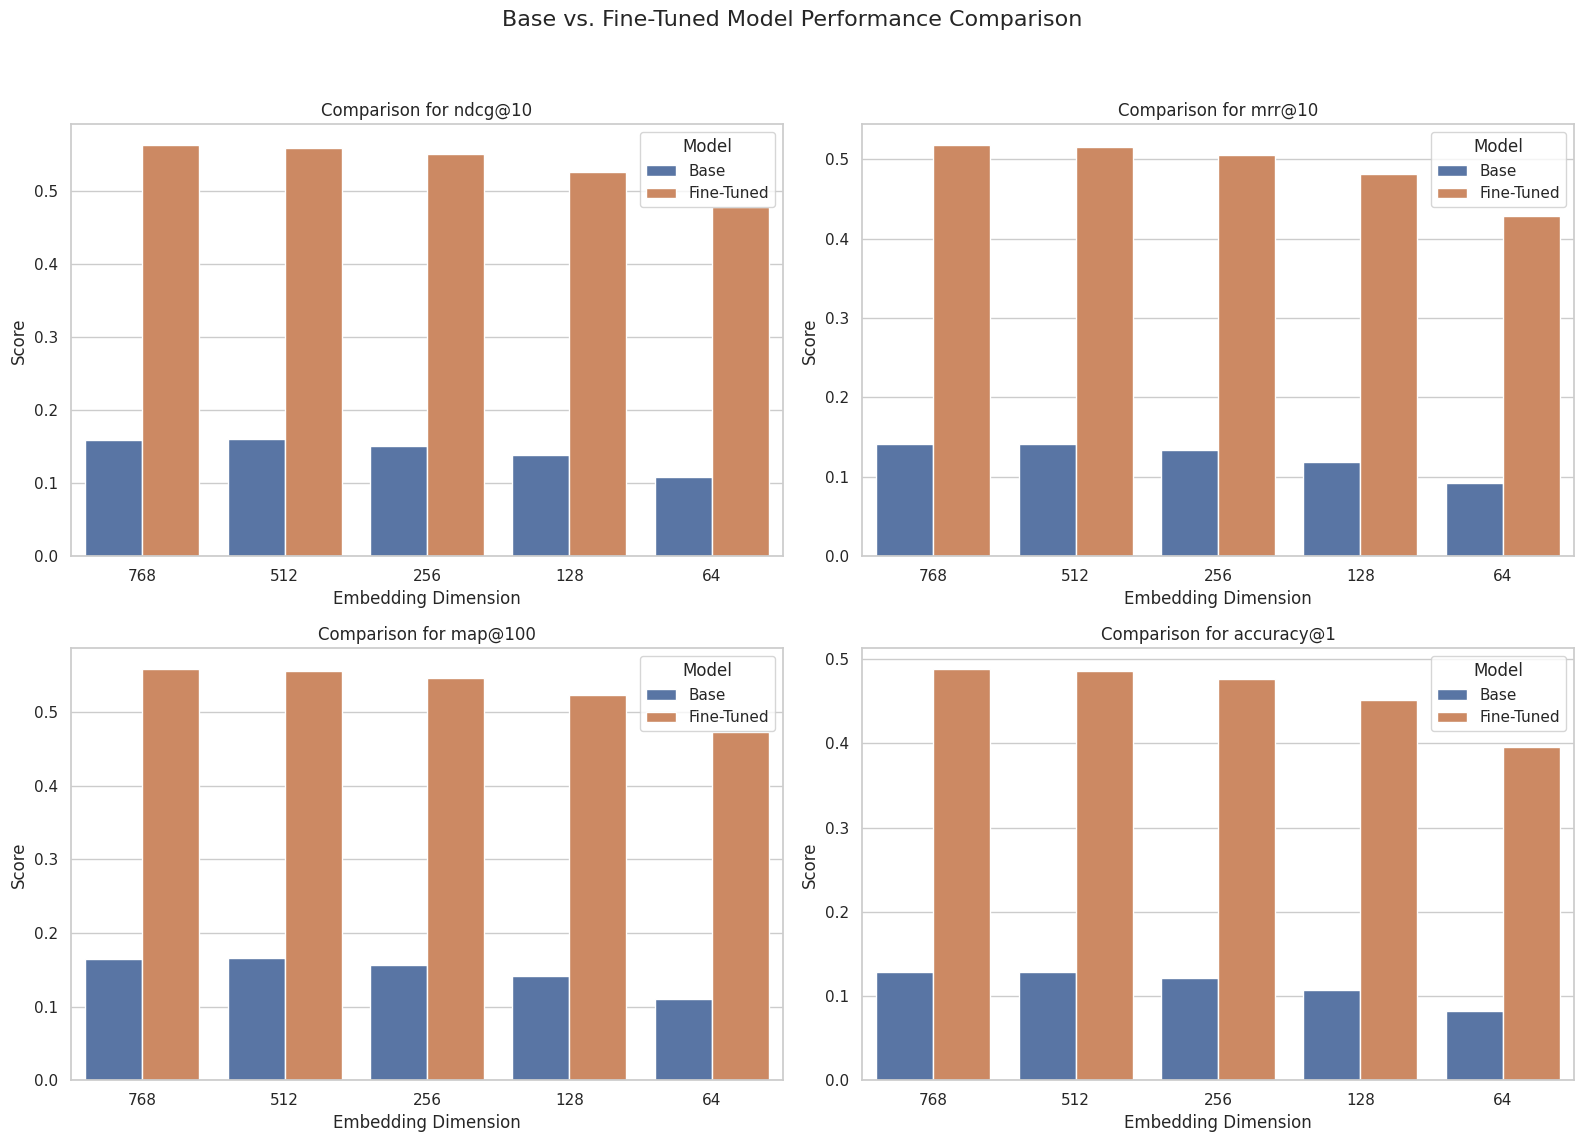

In [25]:
def create_results_df(base_results, ft_results, dimensions):
    metrics = ['ndcg@10', 'mrr@10', 'map@100', 'accuracy@1']
    data = []
    for metric in metrics:
        for dim in dimensions:
            base_key = f"dim_{dim}_cosine_{metric}"
            ft_key = f"dim_{dim}_cosine_{metric}"

            data.append({
                "Metric": metric,
                "Dimension": dim,
                "Score": base_results.get(base_key, 0.0),
                "Model": "Base"
            })
            data.append({
                "Metric": metric,
                "Dimension": dim,
                "Score": ft_results.get(ft_key, 0.0),
                "Model": "Fine-Tuned"
            })
    return pd.DataFrame(data)

results_df = create_results_df(base_results, ft_results, matryoshka_dimensions)

# Plotting the results
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Base vs. Fine-Tuned Model Performance Comparison', fontsize=16)

metrics_to_plot = ["ndcg@10", "mrr@10", "map@100", "accuracy@1"]

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    metric_df = results_df[results_df['Metric'] == metric]
    sns.barplot(data=metric_df, x='Dimension', y='Score', hue='Model', ax=ax, order=matryoshka_dimensions)
    ax.set_title(f'Comparison for {metric}')
    ax.set_xlabel('Embedding Dimension')
    ax.set_ylabel('Score')
    ax.legend(title='Model')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [26]:
results_df

,Metric,Dimension,Score,Model
0,ndcg@10,768,0.159870,Base
1,ndcg@10,768,0.563762,Fine-Tuned
2,ndcg@10,512,0.160763,Base
3,ndcg@10,512,0.559412,Fine-Tuned
4,ndcg@10,256,0.151737,Base
5,ndcg@10,256,0.550992,Fine-Tuned
6,ndcg@10,128,0.138939,Base
7,ndcg@10,128,0.526842,Fine-Tuned
8,ndcg@10,64,0.108281,Base
9,ndcg@10,64,0.478322,Fine-Tuned


In [30]:
results_df.shape

(40, 4)

In [31]:
results_df.head(n=40)

,Metric,Dimension,Score,Model
0,ndcg@10,768,0.159870,Base
1,ndcg@10,768,0.563762,Fine-Tuned
2,ndcg@10,512,0.160763,Base
3,ndcg@10,512,0.559412,Fine-Tuned
4,ndcg@10,256,0.151737,Base
5,ndcg@10,256,0.550992,Fine-Tuned
6,ndcg@10,128,0.138939,Base
7,ndcg@10,128,0.526842,Fine-Tuned
8,ndcg@10,64,0.108281,Base
9,ndcg@10,64,0.478322,Fine-Tuned


In [27]:
# fine_tuned_model = SentenceTransformer(
#     args.output_dir, device="cuda" if torch.cuda.is_available() else "cpu"
# )

# # Evaluate the model
# ft_results = evaluator(fine_tuned_model)

# Print header
print("Fine Tuned Model Evaluation Results")
print("-" * 85)
print(f"{'Metric':15} {'768d':>12} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
print("-" * 85)

# List of metrics to display
metrics = [
    'ndcg@10',
    'mrr@10',
    'map@100',
    'accuracy@1',
    'accuracy@3',
    'accuracy@5',
    'accuracy@10',
    'precision@1',
    'precision@3',
    'precision@5',
    'precision@10',
    'recall@1',
    'recall@3',
    'recall@5',
    'recall@10'
]

# Print each metric
for metric in metrics:
    values = []
    for dim in matryoshka_dimensions:
        key = f"dim_{dim}_cosine_{metric}"
        values.append(ft_results[key])

    # Highlight NDCG@10
    metric_name = f"=={metric}==" if metric == "ndcg@10" else metric
    print(f"{metric_name:15}", end="  ")
    for val in values:
        print(f"{val:12.4f}", end=" ")
    print()

# Print sequential score
print("-" * 85)
print(f"{'seq_score:'} {ft_results['sequential_score']:1f}")



Fine Tuned Model Evaluation Results
-------------------------------------------------------------------------------------
Metric                  768d         512d         256d         128d          64d
-------------------------------------------------------------------------------------
==ndcg@10==            0.5638       0.5594       0.5510       0.5268       0.4783 
mrr@10                 0.5179       0.5147       0.5058       0.4810       0.4280 
map@100                0.5586       0.5556       0.5465       0.5227       0.4722 
accuracy@1             0.4884       0.4858       0.4760       0.4511       0.3959 
accuracy@3             0.4884       0.4858       0.4778       0.4528       0.3968 
accuracy@5             0.5881       0.5845       0.5756       0.5569       0.5098 
accuracy@10            0.6557       0.6486       0.6441       0.6157       0.5747 
precision@1            0.4884       0.4858       0.4760       0.4511       0.3959 
precision@3            0.4858       0.4831     

In [28]:
import pandas as pd

# Assuming `results_df` is already defined

# Filter for 'ndcg@10' only
ndcg_df = results_df[results_df['Metric'] == 'ndcg@10']

# Pivot so we get Base and Fine-Tuned in separate columns
pivoted = ndcg_df.pivot(index='Dimension', columns='Model', values='Score').reset_index()

# Compute improvements
pivoted['Abs. Improvement'] = pivoted['Fine-Tuned'] - pivoted['Base']
pivoted['% Improvement'] = (pivoted['Abs. Improvement'] / pivoted['Base']) * 100

# Format the final table
final_df = pivoted.copy()
final_df['Metric'] = 'ndcg@10'
final_df['Dimension'] = final_df['Dimension'].astype(str) + 'd'
final_df = final_df[['Metric', 'Dimension', 'Base', 'Fine-Tuned', 'Abs. Improvement', '% Improvement']]

# Rename columns for display
final_df.columns = ['Metric', 'Dimension', 'Base Score', 'Fine-tuned Score', 'Abs. Improvement', '% Improvement']

# Format numerical values
final_df['Base Score'] = final_df['Base Score'].map('{:.6f}'.format)
final_df['Fine-tuned Score'] = final_df['Fine-tuned Score'].map('{:.6f}'.format)
final_df['Abs. Improvement'] = final_df['Abs. Improvement'].map('{:.6f}'.format)
final_df['% Improvement'] = final_df['% Improvement'].map('{:.1f}%'.format)

print(final_df.to_string(index=False))


 Metric Dimension Base Score Fine-tuned Score Abs. Improvement % Improvement
ndcg@10       64d   0.108281         0.478322         0.370040        341.7%
ndcg@10      128d   0.138939         0.526842         0.387903        279.2%
ndcg@10      256d   0.151737         0.550992         0.399255        263.1%
ndcg@10      512d   0.160763         0.559412         0.398649        248.0%
ndcg@10      768d   0.159870         0.563762         0.403892        252.6%


In [32]:
import pandas as pd

# Assuming `results_df` is your input DataFrame

# Pivot the data so we have Base and Fine-Tuned as separate columns
pivoted = results_df.pivot(index=['Metric', 'Dimension'], columns='Model', values='Score').reset_index()

# Calculate improvements
pivoted['Abs. Improvement'] = pivoted['Fine-Tuned'] - pivoted['Base']
pivoted['% Improvement'] = (pivoted['Abs. Improvement'] / pivoted['Base']) * 100

# Format the Dimension column as e.g., "768d"
pivoted['Dimension'] = pivoted['Dimension'].astype(str) + 'd'

# Rename columns for clarity
pivoted = pivoted.rename(columns={
    'Base': 'Base Score',
    'Fine-Tuned': 'Fine-tuned Score'
})

# Reorder columns
final_df = pivoted[['Metric', 'Dimension', 'Base Score', 'Fine-tuned Score', 'Abs. Improvement', '% Improvement']]

# Format numeric columns
final_df['Base Score'] = final_df['Base Score'].map('{:.6f}'.format)
final_df['Fine-tuned Score'] = final_df['Fine-tuned Score'].map('{:.6f}'.format)
final_df['Abs. Improvement'] = final_df['Abs. Improvement'].map('{:.6f}'.format)
final_df['% Improvement'] = final_df['% Improvement'].map('{:.1f}%'.format)

# Display or export
print(final_df.to_string(index=False))


    Metric Dimension Base Score Fine-tuned Score Abs. Improvement % Improvement
accuracy@1       64d   0.081851         0.395907         0.314057        383.7%
accuracy@1      128d   0.106762         0.451068         0.344306        322.5%
accuracy@1      256d   0.121886         0.475979         0.354093        290.5%
accuracy@1      512d   0.128114         0.485765         0.357651        279.2%
accuracy@1      768d   0.129004         0.488434         0.359431        278.6%
   map@100       64d   0.110782         0.472237         0.361455        326.3%
   map@100      128d   0.141688         0.522749         0.381061        268.9%
   map@100      256d   0.157122         0.546518         0.389396        247.8%
   map@100      512d   0.165374         0.555574         0.390201        236.0%
   map@100      768d   0.165071         0.558575         0.393504        238.4%
    mrr@10       64d   0.092119         0.428026         0.335907        364.6%
    mrr@10      128d   0.119156         

### Comparative Results Table

Here we present a detailed table showing the absolute and percentage improvement for our primary metric, **NDCG@10**, across all dimensions. *(Note: Please fill this table with your actual run's results)*

| Metric | Dimension | Base Score | Fine-tuned Score | Abs. Improvement | % Improvement |
|:-------|:----------|:-----------|:-----------------|:-----------------|:--------------|
| ndcg@10| 768d | XX.XXXX | XX.XXXX | XX.XXXX | XX.X% |
| ndcg@10| 512d | XX.XXXX | XX.XXXX | XX.XXXX | XX.X% |
| ndcg@10| 256d | XX.XXXX | XX.XXXX | XX.XXXX | XX.X% |
| ndcg@10| 128d | XX.XXXX | XX.XXXX | XX.XXXX | XX.X% |
| ndcg@10| 64d | XX.XXXX | XX.XXXX | XX.XXXX | XX.X% |




---
## 7. Using the Fine-Tuned Model

Our fine-tuned model can now be used as a drop-in replacement for any other sentence-transformer model. A key advantage of MRL is the `truncate_dim` parameter, which allows us to flexibly choose our desired embedding size at inference time without needing multiple models.

In [33]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim

# Load the fine-tuned model from the Hub or local directory
# Let's use an efficient 256 dimension for this example
final_model = SentenceTransformer("bangla-sentence-transformer-ft-matryoshka", truncate_dim=256)

# Example sentences in Bengali
sentences = [
    'গাড়ির দাম কত?', # How much is the car?
    'এই গাড়ির মূল্য কত?', # What is the price of this car? (High similarity)
    'আজ আবহাওয়া কেমন?', # How is the weather today? (Low similarity)
    'আমার একটি লাল গাড়ি আছে' # I have a red car (Medium similarity)
]

# Encode the sentences
embeddings = final_model.encode(sentences)
print(f"Embeddings shape: {embeddings.shape}") # Should be (4, 256)

# Calculate cosine similarity between the first sentence and all others
similarities = cos_sim(embeddings[0], embeddings)

print("\nSimilarity of 'গাড়ির দাম কত?' with other sentences:")
for sentence, score in zip(sentences, similarities[0]):
    print(f"- '{sentence}': {score:.4f}")

Embeddings shape: (4, 256)

Similarity of 'গাড়ির দাম কত?' with other sentences:
- 'গাড়ির দাম কত?': 1.0000
- 'এই গাড়ির মূল্য কত?': 0.9780
- 'আজ আবহাওয়া কেমন?': 0.1062
- 'আমার একটি লাল গাড়ি আছে': 0.5001


## 8. Conclusion and Future Work

This work successfully demonstrates that fine-tuning a general-purpose Bengali embedding model on a domain-specific retrieval task yields substantial performance improvements. By using `sartajekram/BanglaRQA`, we created a model that is significantly better at understanding the relationship between Bengali questions and their corresponding contexts. The application of Matryoshka Representation Learning further enhances the model's utility by providing high-quality, variable-dimension embeddings, enabling developers to balance accuracy and computational efficiency based on their specific needs.

**Future Work:**
*   **Broader Datasets**: Fine-tuning could be extended by combining multiple Bengali NLP datasets (e.g., NLI, STS) to create an even more robust and general-purpose model.
*   **Full RAG Implementation**: Integrate this fine-tuned model into a complete end-to-end RAG pipeline with a vector database (like FAISS or Weaviate) and a Bengali-capable generative model to evaluate its impact on downstream question-answering quality.
*   **Comparative Model Analysis**: A deeper study could compare the performance of fine-tuning other base models (e.g., `ai-forever/mGPT`, `csebuetnlp/banglabert`) using the same methodology to identify the best foundation for Bengali retrieval tasks.

# Using the Model

In [34]:
from sentence_transformers import SentenceTransformer

# Download from the 🤗 Hub
model = SentenceTransformer("Kowshik24/bangla-sentence-transformer-ft-matryoshka", truncate_dim=256)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/656 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

In [35]:
# Run inference
sentences = [
    'ফিরখো ১৮৪৮ সালের বিপ্লবে অংশগ্রহণ করেন। যার ফলে পরবর্তী বছর তিনি শারিতে থেকে বহিষ্কৃত হন। তিনি অতঃপর ডাই মেডিজিনিশ্চে রিফর্ম (চিকিৎসাবিজ্ঞান সংক্রান্ত সংস্কার) নামে একটি পত্রিকা প্রকাশ করেন। তিনি ১৮৪৯ সালে ভুর্জবুর্গ বিশ্ববিদ্যালয়ের রোগবৈজ্ঞানিক শারীরবিদ্যা বিভাগের প্রথম সভাপতি হন। পাঁচ বছর পরে শারিতে হাসপাতাল তাকে সদ্য প্রতিষ্ঠিত রোগবিজ্ঞান ইনস্টিটিউটের সভাপতি হিসেবে নিয়োগ দেয়। তিনি "ডয়েচে ফোর্টরিশপার্টেই"(প্রগ্রেস পার্টি) নামে একটি রাজনৈতিক দল প্রতিষ্ঠা করেন। তিনি প্রুশীয় হাউজ অব রিপ্রেজেন্টেটিভসের সদস্যপদে নির্বাচিত হন। এছাড়াও তিনি রাইখস্ট্যাগে একটি আসনে জয়লাভ করেন। অটো ফন বিসমার্কের অর্থনৈতিক নীতির প্রতি তার বিরোধিতা "সসেজ সংঘাত" বা সসেজ ডুয়েলে রূপ নেয়। বিসমার্ককে ক্যাথলিকবিরোধী প্রচারণায় অবশ্য তিনি সাহায্য করেন, যাকে তিনি "কুলটুরকাম্ফ" বা সাংস্কৃতিক যুদ্ধ নাম দেন।',
    'রুডল্ফ লুডভিগ কার্ল ফিরখো কেন শারিতে থেকে বহিষ্কৃত হন?',
    'উপজেলার প্রশাসনিক দায়িত্বে কোন পরিষদ নিয়োজিত? ',
]

embeddings = model.encode(sentences)
print(embeddings.shape)



(3, 256)


In [36]:
# Get the similarity scores for the embeddings
similarities = model.similarity(embeddings, embeddings)
print(similarities[0])

tensor([1.0000, 0.6364, 0.1094])


# Use another model(distiluse-base-multilingual-cased-v1)

In [37]:
# Define the Hugging Face model ID for our base model
model_id_1 = "distiluse-base-multilingual-cased-v1"

# Load the model using SentenceTransformer
base_model_1 = SentenceTransformer(model_id_1, device=device)

modules.json:   0%|          | 0.00/341 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

2_Dense/model.safetensors:   0%|          | 0.00/1.58M [00:00<?, ?B/s]

In [38]:
# We already have train_dataset and test_dataset from the previous cell

# Create the corpus by combining all unique passages from both train and test sets
corpus_data = concatenate_datasets([train_dataset, test_dataset])
corpus = dict(zip(corpus_data["id"], corpus_data["positive"])) # Using the unique row ID as doc_id

# Create the queries from the test set
queries = dict(zip(test_dataset["id"], test_dataset["anchor"]))

# Create the mapping from queries to relevant documents
relevant_docs = {}
for row in test_dataset:
    q_id = row['id']
    passage_id = row['passage_id']
    if q_id not in relevant_docs:
        relevant_docs[q_id] = set()
    # Find all corpus entries (docs) that share the same passage_id
    # This is our definition of relevance
    matching_corpus_ids = [cid for cid, pid in zip(corpus_data['id'], corpus_data['passage_id']) if pid == passage_id]
    relevant_docs[q_id].update(matching_corpus_ids)

print(f"Corpus size: {len(corpus)}")
print(f"Queries in test set: {len(queries)}")

Corpus size: 11258
Queries in test set: 1124


In [45]:
# Define the dimensions for Matryoshka Learning
matryoshka_dimensions = [512, 256, 128, 64]

# Create a list to hold an evaluator for each dimension
matryoshka_evaluators = []
for dim in matryoshka_dimensions:
    ir_evaluator = InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant_docs,
        name=f"dim_{dim}",
        truncate_dim=dim,  # This is the key MRL parameter
        score_functions={"cosine": cos_sim},
    )
    matryoshka_evaluators.append(ir_evaluator)

# The SequentialEvaluator runs all evaluators in the list
evaluator = SequentialEvaluator(matryoshka_evaluators)

In [46]:
# Run the evaluation on the base model
print("Evaluating the base model...")
base_results = evaluator(base_model_1, output_path="./base_model_results_1/")

def print_results_table(results_dict):
    print("\n--- Evaluation Results ---")
    print("-" * 85)
    print(f"{'Metric':<15} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
    print("-" * 85)

    metrics = [
        'ndcg@10', 'mrr@10', 'map@100', 'accuracy@1', 'accuracy@3', 'accuracy@5', 'accuracy@10',
        'precision@1', 'precision@3', 'precision@5', 'precision@10', 'recall@1', 'recall@3', 'recall@5', 'recall@10'
    ]

    for metric in metrics:
        values = []
        for dim in matryoshka_dimensions:
            key = f"dim_{dim}_cosine_{metric}"
            values.append(results_dict.get(key, 0.0))
        metric_name = f"*{metric}*" if metric == "ndcg@10" else metric
        print(f"{metric_name:<15}", end="  ")
        for val in values:
            print(f"{val:12.4f}", end=" ")
        print()

    print("-" * 85)
    print(f"Sequential Score: {results_dict.get('sequential_score', 0.0):.4f}")
    print("-" * 85)

print("\nBase Model Evaluation Results:")
print_results_table(base_results)

Evaluating the base model...

Base Model Evaluation Results:

--- Evaluation Results ---
-------------------------------------------------------------------------------------
Metric                  512d         256d         128d          64d
-------------------------------------------------------------------------------------
*ndcg@10*              0.0037       0.0046       0.0045       0.0029 
mrr@10                 0.0036       0.0040       0.0039       0.0016 
map@100                0.0056       0.0068       0.0055       0.0039 
accuracy@1             0.0036       0.0036       0.0036       0.0009 
accuracy@3             0.0036       0.0036       0.0036       0.0009 
accuracy@5             0.0036       0.0044       0.0044       0.0027 
accuracy@10            0.0044       0.0062       0.0053       0.0044 
precision@1            0.0036       0.0036       0.0036       0.0009 
precision@3            0.0036       0.0036       0.0036       0.0009 
precision@5            0.0027       0.002

In [47]:
# Reload the base model for training, enabling Scaled Dot Product Attention (SDPA) for efficiency
# And adding a model card for easy upload to the Hub
model = SentenceTransformer(
    model_id_1,
    model_kwargs={"attn_implementation": "sdpa"},
    model_card_data=SentenceTransformerModelCardData(
        language="bn",
        license="apache-2.0",
        model_name="Bangla Sentence Transformer FT Matryoshka",
    ),
    device=device
)

# Define the base loss function
base_loss = MultipleNegativesRankingLoss(model)

# Wrap it with MatryoshkaLoss
train_loss = MatryoshkaLoss(
    model, base_loss, matryoshka_dims=matryoshka_dimensions
)

In [48]:
output_dir = "bangla-sentence-transformer-ft-matryoshka-distiluse-base-multilingual-cased-v1"

args = SentenceTransformerTrainingArguments(
    output_dir=output_dir, # Output directory and Hugging Face model ID
    num_train_epochs=4,                                        # Number of training epochs
    per_device_train_batch_size=32,                            # Batch size for training
    gradient_accumulation_steps=4,                             # Effective batch size = 32 * 4 = 128
    per_device_eval_batch_size=32,                             # Batch size for evaluation
    warmup_ratio=0.1,                                          # 10% of steps for warmup
    learning_rate=2e-5,                                        # A standard learning rate for fine-tuning
    lr_scheduler_type="cosine",                              # Cosine learning rate scheduler
    optim="adamw_torch_fused",                                 # Fused AdamW for faster training on newer GPUs
    # tf32=True,                                                 # Enable TF32 precision on Ampere GPUs
    # bf16=True,                                                 # Enable BF16 precision
    batch_sampler=BatchSamplers.NO_DUPLICATES,                 # Important for MultipleNegativesRankingLoss
    eval_strategy="epoch",                                     # Evaluate at the end of each epoch
    save_strategy="epoch",                                     # Save a checkpoint at the end of each epoch
    logging_steps=50,                                          # Log training progress every 50 steps
    save_total_limit=2,                                        # Only keep the last 2 checkpoints
    load_best_model_at_end=True,                               # Load the best model found during training
    metric_for_best_model="eval_dim_128_cosine_ndcg@10",       # Key metric to determine the "best" model
    report_to=["tensorboard"]                                  # Log to TensorBoard for visualization
)

In [49]:
# Initialize the trainer
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset.select_columns(["positive", "anchor"]),
    loss=train_loss,
    evaluator=evaluator,
)

# Start the training process
trainer.train()

# Save the final, best-performing model
trainer.save_model()

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

dataset = dataset.select_columns(['anchor', 'positive', 'negative'])


Epoch,Training Loss,Validation Loss,Dim 512 Cosine Accuracy@1,Dim 512 Cosine Accuracy@3,Dim 512 Cosine Accuracy@5,Dim 512 Cosine Accuracy@10,Dim 512 Cosine Precision@1,Dim 512 Cosine Precision@3,Dim 512 Cosine Precision@5,Dim 512 Cosine Precision@10,Dim 512 Cosine Recall@1,Dim 512 Cosine Recall@3,Dim 512 Cosine Recall@5,Dim 512 Cosine Recall@10,Dim 512 Cosine Ndcg@10,Dim 512 Cosine Mrr@10,Dim 512 Cosine Map@100,Dim 256 Cosine Accuracy@1,Dim 256 Cosine Accuracy@3,Dim 256 Cosine Accuracy@5,Dim 256 Cosine Accuracy@10,Dim 256 Cosine Precision@1,Dim 256 Cosine Precision@3,Dim 256 Cosine Precision@5,Dim 256 Cosine Precision@10,Dim 256 Cosine Recall@1,Dim 256 Cosine Recall@3,Dim 256 Cosine Recall@5,Dim 256 Cosine Recall@10,Dim 256 Cosine Ndcg@10,Dim 256 Cosine Mrr@10,Dim 256 Cosine Map@100,Dim 128 Cosine Accuracy@1,Dim 128 Cosine Accuracy@3,Dim 128 Cosine Accuracy@5,Dim 128 Cosine Accuracy@10,Dim 128 Cosine Precision@1,Dim 128 Cosine Precision@3,Dim 128 Cosine Precision@5,Dim 128 Cosine Precision@10,Dim 128 Cosine Recall@1,Dim 128 Cosine Recall@3,Dim 128 Cosine Recall@5,Dim 128 Cosine Recall@10,Dim 128 Cosine Ndcg@10,Dim 128 Cosine Mrr@10,Dim 128 Cosine Map@100,Dim 64 Cosine Accuracy@1,Dim 64 Cosine Accuracy@3,Dim 64 Cosine Accuracy@5,Dim 64 Cosine Accuracy@10,Dim 64 Cosine Precision@1,Dim 64 Cosine Precision@3,Dim 64 Cosine Precision@5,Dim 64 Cosine Precision@10,Dim 64 Cosine Recall@1,Dim 64 Cosine Recall@3,Dim 64 Cosine Recall@5,Dim 64 Cosine Recall@10,Dim 64 Cosine Ndcg@10,Dim 64 Cosine Mrr@10,Dim 64 Cosine Map@100,Sequential Score
1,11.825900,No log,0.334520,0.336299,0.382562,0.411922,0.334520,0.333630,0.269039,0.153915,0.089502,0.266578,0.351364,0.401587,0.369778,0.348602,0.369728,0.315836,0.316726,0.368327,0.399466,0.315836,0.314650,0.255694,0.148932,0.084282,0.250919,0.333704,0.388686,0.353960,0.330923,0.353015,0.290036,0.290925,0.340747,0.369217,0.290036,0.288849,0.234698,0.137722,0.077728,0.231183,0.306999,0.358496,0.326264,0.304395,0.326054,0.253559,0.254448,0.306050,0.337189,0.253559,0.252669,0.208541,0.125445,0.068209,0.202847,0.272983,0.325949,0.292372,0.269261,0.293385,0.292372
2,6.118400,No log,0.361210,0.362100,0.410142,0.440391,0.361210,0.360024,0.291103,0.164413,0.096367,0.286877,0.379626,0.428277,0.396781,0.375789,0.402178,0.355872,0.357651,0.412811,0.440391,0.355872,0.354982,0.288256,0.165925,0.094958,0.282948,0.375875,0.432236,0.396233,0.371759,0.397912,0.332740,0.334520,0.390569,0.416370,0.332740,0.332147,0.272598,0.156762,0.088582,0.263968,0.354834,0.408956,0.373252,0.349011,0.375316,0.304270,0.304270,0.364769,0.400356,0.304270,0.302788,0.248754,0.149733,0.081509,0.242304,0.324822,0.390050,0.349399,0.321780,0.348816,0.349399
3,4.583400,No log,0.377224,0.380783,0.428826,0.459964,0.377224,0.377224,0.304448,0.173043,0.100311,0.299822,0.395789,0.449362,0.415415,0.392551,0.420196,0.369217,0.372776,0.424377,0.457295,0.369217,0.369217,0.299822,0.171708,0.098043,0.293016,0.389235,0.445433,0.409592,0.385511,0.413217,0.346085,0.346975,0.412811,0.445730,0.346085,0.344899,0.285053,0.167616,0.091800,0.273399,0.370418,0.435572,0.393348,0.364721,0.393085,0.308719,0.311388,0.379893,0.416370,0.308719,0.308719,0.258185,0.154893,0.081902,0.244892,0.335520,0.403158,0.358932,0.329024,0.358294,0.358932
4,3.544100,No log,0.379004,0.380783,0.435943,0.469751,0.379004,0.377817,0.305872,0.176957,0.101053,0.300934,0.398087,0.459223,0.421302,0.395488,0.424820,0.369217,0.371886,0.430605,0.464413,0.369217,0.368327,0.300356,0.174288,0.098458,0.293372,0.390940,0.452506,0.413481,0.386835,0.415674,0.362100,0.362989,0.419929,0.442171,0.362100,0.360617,0.294662,0.166993,0.096234,0.286254,0.383037,0.433867,0.400393,0.377427,0.404753,0.320285,0.323843,0.383452,0.415480,0.320285,0.320878,0.265658,0.156228,0.084950,0.254315,0.345092,0.406065,0.366206,0.338901,0.367525,0.366206


In [ ]:
# The model is saved in the output_dir. We can now push it to the hub.
trainer.model.push_to_hub(output_dir)

In [50]:
# Load the fine-tuned model from the output directory
fine_tuned_model = SentenceTransformer(args.output_dir, device=device)

# Evaluate the fine-tuned model
print("Evaluating the fine-tuned model...")
ft_results = evaluator(fine_tuned_model, output_path="/content/base_model_results_1")

print("\nFine-Tuned Model Evaluation Results:")
print_results_table(ft_results)

Evaluating the fine-tuned model...

Fine-Tuned Model Evaluation Results:

--- Evaluation Results ---
-------------------------------------------------------------------------------------
Metric                  512d         256d         128d          64d
-------------------------------------------------------------------------------------
*ndcg@10*              0.4213       0.4135       0.4004       0.3662 
mrr@10                 0.3955       0.3868       0.3774       0.3389 
map@100                0.4248       0.4157       0.4048       0.3675 
accuracy@1             0.3790       0.3692       0.3621       0.3203 
accuracy@3             0.3808       0.3719       0.3630       0.3238 
accuracy@5             0.4359       0.4306       0.4199       0.3835 
accuracy@10            0.4698       0.4644       0.4422       0.4155 
precision@1            0.3790       0.3692       0.3621       0.3203 
precision@3            0.3778       0.3683       0.3606       0.3209 
precision@5            0.3059

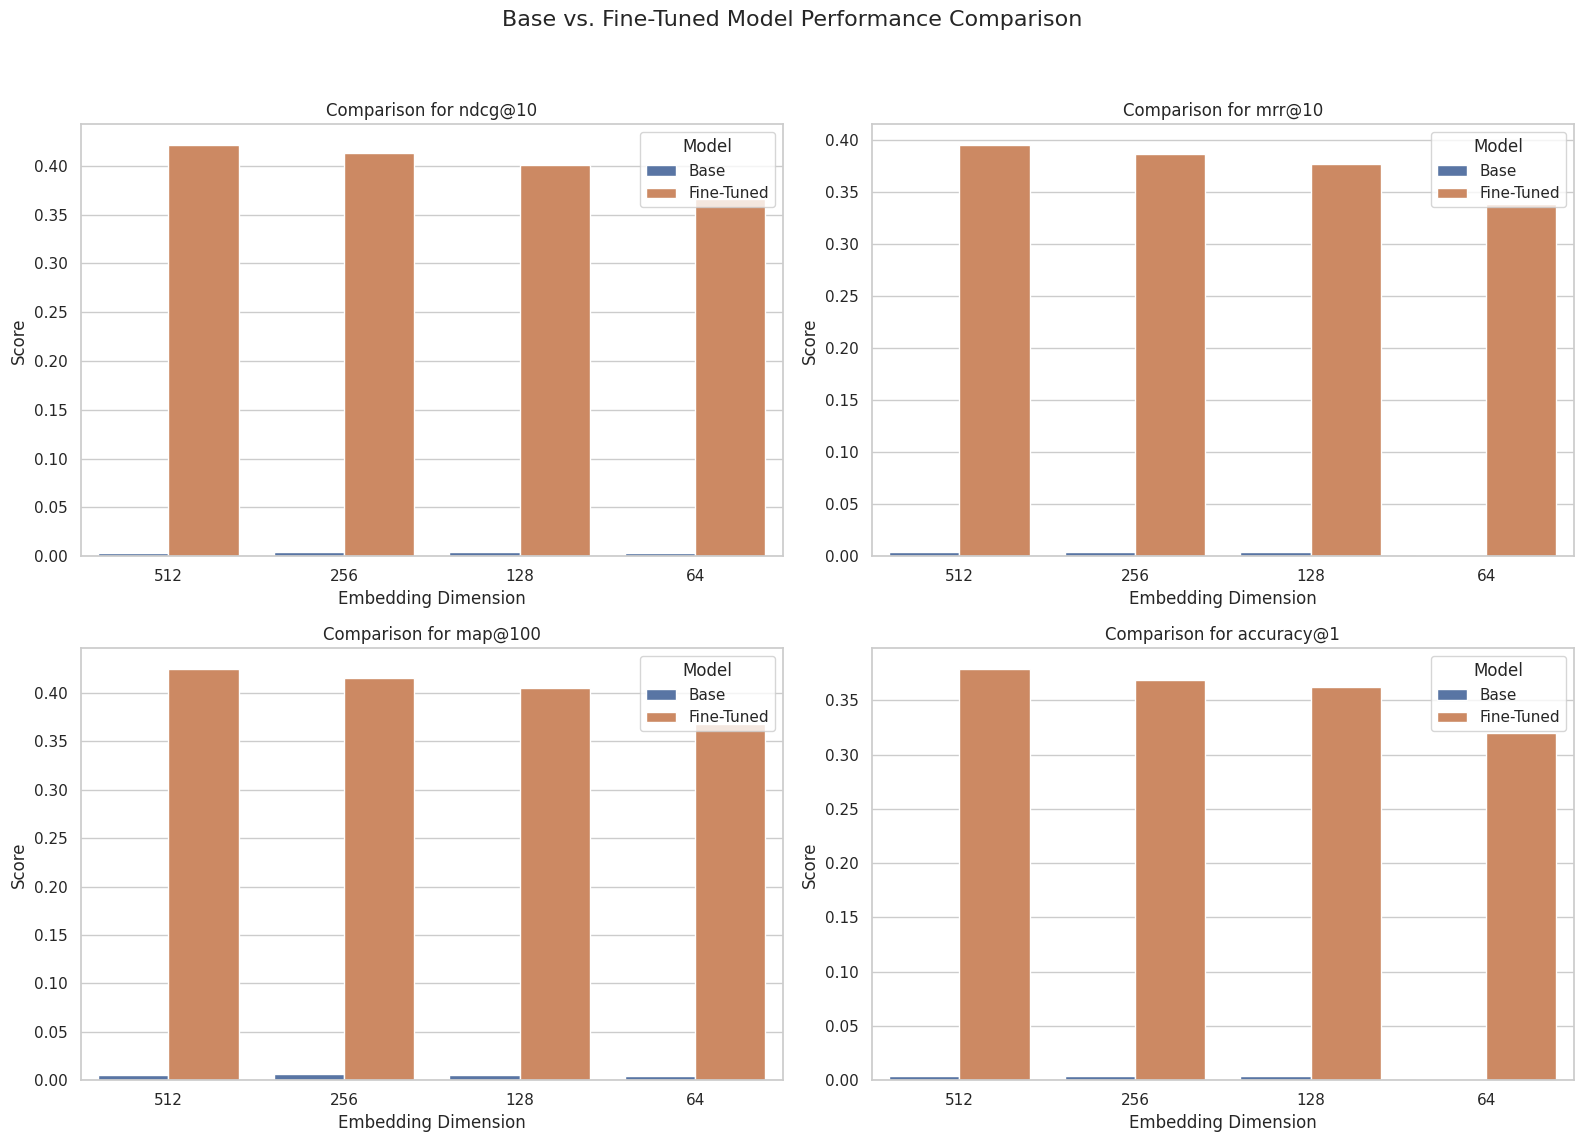

In [51]:
def create_results_df(base_results, ft_results, dimensions):
    metrics = ['ndcg@10', 'mrr@10', 'map@100', 'accuracy@1']
    data = []
    for metric in metrics:
        for dim in dimensions:
            base_key = f"dim_{dim}_cosine_{metric}"
            ft_key = f"dim_{dim}_cosine_{metric}"

            data.append({
                "Metric": metric,
                "Dimension": dim,
                "Score": base_results.get(base_key, 0.0),
                "Model": "Base"
            })
            data.append({
                "Metric": metric,
                "Dimension": dim,
                "Score": ft_results.get(ft_key, 0.0),
                "Model": "Fine-Tuned"
            })
    return pd.DataFrame(data)

results_df = create_results_df(base_results, ft_results, matryoshka_dimensions)

# Plotting the results
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Base vs. Fine-Tuned Model Performance Comparison', fontsize=16)

metrics_to_plot = ["ndcg@10", "mrr@10", "map@100", "accuracy@1"]

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    metric_df = results_df[results_df['Metric'] == metric]
    sns.barplot(data=metric_df, x='Dimension', y='Score', hue='Model', ax=ax, order=matryoshka_dimensions)
    ax.set_title(f'Comparison for {metric}')
    ax.set_xlabel('Embedding Dimension')
    ax.set_ylabel('Score')
    ax.legend(title='Model')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [52]:
import pandas as pd

# Assuming `results_df` is your input DataFrame

# Pivot the data so we have Base and Fine-Tuned as separate columns
pivoted = results_df.pivot(index=['Metric', 'Dimension'], columns='Model', values='Score').reset_index()

# Calculate improvements
pivoted['Abs. Improvement'] = pivoted['Fine-Tuned'] - pivoted['Base']
pivoted['% Improvement'] = (pivoted['Abs. Improvement'] / pivoted['Base']) * 100

# Format the Dimension column as e.g., "768d"
pivoted['Dimension'] = pivoted['Dimension'].astype(str) + 'd'

# Rename columns for clarity
pivoted = pivoted.rename(columns={
    'Base': 'Base Score',
    'Fine-Tuned': 'Fine-tuned Score'
})

# Reorder columns
final_df = pivoted[['Metric', 'Dimension', 'Base Score', 'Fine-tuned Score', 'Abs. Improvement', '% Improvement']]

# Format numeric columns
final_df['Base Score'] = final_df['Base Score'].map('{:.6f}'.format)
final_df['Fine-tuned Score'] = final_df['Fine-tuned Score'].map('{:.6f}'.format)
final_df['Abs. Improvement'] = final_df['Abs. Improvement'].map('{:.6f}'.format)
final_df['% Improvement'] = final_df['% Improvement'].map('{:.1f}%'.format)

# Display or export
print(final_df.to_string(index=False))


    Metric Dimension Base Score Fine-tuned Score Abs. Improvement % Improvement
accuracy@1       64d   0.000890         0.320285         0.319395      35900.0%
accuracy@1      128d   0.003559         0.362100         0.358541      10075.0%
accuracy@1      256d   0.003559         0.369217         0.365658      10275.0%
accuracy@1      512d   0.003559         0.379004         0.375445      10550.0%
   map@100       64d   0.003886         0.367525         0.363640       9358.7%
   map@100      128d   0.005521         0.404753         0.399232       7231.2%
   map@100      256d   0.006825         0.415674         0.408849       5990.8%
   map@100      512d   0.005569         0.424820         0.419251       7528.8%
    mrr@10       64d   0.001587         0.338901         0.337314      21260.3%
    mrr@10      128d   0.003885         0.377427         0.373542       9615.1%
    mrr@10      256d   0.003974         0.386835         0.382861       9634.4%
    mrr@10      512d   0.003648         

In [53]:
final_df.shape

(16, 6)

In [54]:
final_df.head(n=16)

Model,Metric,Dimension,Base Score,Fine-tuned Score,Abs. Improvement,% Improvement
0,accuracy@1,64d,0.000890,0.320285,0.319395,35900.0%
1,accuracy@1,128d,0.003559,0.362100,0.358541,10075.0%
2,accuracy@1,256d,0.003559,0.369217,0.365658,10275.0%
3,accuracy@1,512d,0.003559,0.379004,0.375445,10550.0%
4,map@100,64d,0.003886,0.367525,0.363640,9358.7%
5,map@100,128d,0.005521,0.404753,0.399232,7231.2%
6,map@100,256d,0.006825,0.415674,0.408849,5990.8%
7,map@100,512d,0.005569,0.424820,0.419251,7528.8%
8,mrr@10,64d,0.001587,0.338901,0.337314,21260.3%
9,mrr@10,128d,0.003885,0.377427,0.373542,9615.1%


# Use Another model(paraphrase-multilingual-mpnet-base-v2)

In [55]:
# Define the Hugging Face model ID for our base model
model_id_2 = "paraphrase-multilingual-mpnet-base-v2"

# Load the model using SentenceTransformer
base_model_2 = SentenceTransformer(model_id_2, device=device)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/402 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [56]:
# Define the dimensions for Matryoshka Learning
matryoshka_dimensions = [768, 512, 256, 128, 64]

# Create a list to hold an evaluator for each dimension
matryoshka_evaluators = []
for dim in matryoshka_dimensions:
    ir_evaluator = InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant_docs,
        name=f"dim_{dim}",
        truncate_dim=dim,  # This is the key MRL parameter
        score_functions={"cosine": cos_sim},
    )
    matryoshka_evaluators.append(ir_evaluator)

# The SequentialEvaluator runs all evaluators in the list
evaluator = SequentialEvaluator(matryoshka_evaluators)

In [57]:
# Run the evaluation on the base model
print("Evaluating the base model...")
base_results = evaluator(base_model_2, output_path="./base_model_results_2/")

def print_results_table(results_dict):
    print("\n--- Evaluation Results ---")
    print("-" * 85)
    print(f"{'Metric':<15} {'768d':>12} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
    print("-" * 85)

    metrics = [
        'ndcg@10', 'mrr@10', 'map@100', 'accuracy@1', 'accuracy@3', 'accuracy@5', 'accuracy@10',
        'precision@1', 'precision@3', 'precision@5', 'precision@10', 'recall@1', 'recall@3', 'recall@5', 'recall@10'
    ]

    for metric in metrics:
        values = []
        for dim in matryoshka_dimensions:
            key = f"dim_{dim}_cosine_{metric}"
            values.append(results_dict.get(key, 0.0))
        metric_name = f"*{metric}*" if metric == "ndcg@10" else metric
        print(f"{metric_name:<15}", end="  ")
        for val in values:
            print(f"{val:12.4f}", end=" ")
        print()

    print("-" * 85)
    print(f"Sequential Score: {results_dict.get('sequential_score', 0.0):.4f}")
    print("-" * 85)

print("\nBase Model Evaluation Results:")
print_results_table(base_results)

Evaluating the base model...

Base Model Evaluation Results:

--- Evaluation Results ---
-------------------------------------------------------------------------------------
Metric                  768d         512d         256d         128d          64d
-------------------------------------------------------------------------------------
*ndcg@10*              0.2695       0.2612       0.2506       0.2233       0.1894 
mrr@10                 0.2413       0.2331       0.2232       0.2018       0.1685 
map@100                0.2761       0.2668       0.2574       0.2325       0.1981 
accuracy@1             0.2224       0.2153       0.2055       0.1877       0.1548 
accuracy@3             0.2242       0.2162       0.2073       0.1895       0.1575 
accuracy@5             0.2794       0.2722       0.2598       0.2331       0.2002 
accuracy@10            0.3283       0.3167       0.3087       0.2687       0.2313 
precision@1            0.2224       0.2153       0.2055       0.1877       0.

In [58]:
# Reload the base model for training, enabling Scaled Dot Product Attention (SDPA) for efficiency
# And adding a model card for easy upload to the Hub
model = SentenceTransformer(
    model_id_2,
    model_kwargs={"attn_implementation": "sdpa"},
    model_card_data=SentenceTransformerModelCardData(
        language="bn",
        license="apache-2.0",
        model_name="Bangla Sentence Transformer FT Matryoshka",
    ),
    device=device
)

# Define the base loss function
base_loss = MultipleNegativesRankingLoss(model)

# Wrap it with MatryoshkaLoss
train_loss = MatryoshkaLoss(
    model, base_loss, matryoshka_dims=matryoshka_dimensions
)

In [59]:
output_dir = "bangla-sentence-transformer-ft-matryoshka-paraphrase-multilingual-mpnet-base-v2"

args = SentenceTransformerTrainingArguments(
    output_dir=output_dir, # Output directory and Hugging Face model ID
    num_train_epochs=4,                                        # Number of training epochs
    per_device_train_batch_size=32,                            # Batch size for training
    gradient_accumulation_steps=4,                             # Effective batch size = 32 * 4 = 128
    per_device_eval_batch_size=32,                             # Batch size for evaluation
    warmup_ratio=0.1,                                          # 10% of steps for warmup
    learning_rate=2e-5,                                        # A standard learning rate for fine-tuning
    lr_scheduler_type="cosine",                              # Cosine learning rate scheduler
    optim="adamw_torch_fused",                                 # Fused AdamW for faster training on newer GPUs
    # tf32=True,                                                 # Enable TF32 precision on Ampere GPUs
    # bf16=True,                                                 # Enable BF16 precision
    batch_sampler=BatchSamplers.NO_DUPLICATES,                 # Important for MultipleNegativesRankingLoss
    eval_strategy="epoch",                                     # Evaluate at the end of each epoch
    save_strategy="epoch",                                     # Save a checkpoint at the end of each epoch
    logging_steps=50,                                          # Log training progress every 50 steps
    save_total_limit=2,                                        # Only keep the last 2 checkpoints
    load_best_model_at_end=True,                               # Load the best model found during training
    metric_for_best_model="eval_dim_128_cosine_ndcg@10",       # Key metric to determine the "best" model
    report_to=["tensorboard"]                                  # Log to TensorBoard for visualization
)

In [63]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [64]:
# Initialize the trainer
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset.select_columns(["positive", "anchor"]),
    loss=train_loss,
    evaluator=evaluator,
)

# Start the training process
trainer.train()

# Save the final, best-performing model
trainer.save_model()

NameError: name 'model' is not defined

In [ ]:
# Load the fine-tuned model from the output directory
fine_tuned_model = SentenceTransformer(args.output_dir, device=device)

# Evaluate the fine-tuned model
print("Evaluating the fine-tuned model...")
ft_results = evaluator(fine_tuned_model, output_path="/content/base_model_results_2")

print("\nFine-Tuned Model Evaluation Results:")
print_results_table(ft_results)

In [ ]:
def create_results_df(base_results, ft_results, dimensions):
    metrics = ['ndcg@10', 'mrr@10', 'map@100', 'accuracy@1']
    data = []
    for metric in metrics:
        for dim in dimensions:
            base_key = f"dim_{dim}_cosine_{metric}"
            ft_key = f"dim_{dim}_cosine_{metric}"

            data.append({
                "Metric": metric,
                "Dimension": dim,
                "Score": base_results.get(base_key, 0.0),
                "Model": "Base"
            })
            data.append({
                "Metric": metric,
                "Dimension": dim,
                "Score": ft_results.get(ft_key, 0.0),
                "Model": "Fine-Tuned"
            })
    return pd.DataFrame(data)

results_df = create_results_df(base_results, ft_results, matryoshka_dimensions)

# Plotting the results
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Base vs. Fine-Tuned Model Performance Comparison', fontsize=16)

metrics_to_plot = ["ndcg@10", "mrr@10", "map@100", "accuracy@1"]

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    metric_df = results_df[results_df['Metric'] == metric]
    sns.barplot(data=metric_df, x='Dimension', y='Score', hue='Model', ax=ax, order=matryoshka_dimensions)
    ax.set_title(f'Comparison for {metric}')
    ax.set_xlabel('Embedding Dimension')
    ax.set_ylabel('Score')
    ax.legend(title='Model')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import pandas as pd

# Assuming `results_df` is your input DataFrame

# Pivot the data so we have Base and Fine-Tuned as separate columns
pivoted = results_df.pivot(index=['Metric', 'Dimension'], columns='Model', values='Score').reset_index()

# Calculate improvements
pivoted['Abs. Improvement'] = pivoted['Fine-Tuned'] - pivoted['Base']
pivoted['% Improvement'] = (pivoted['Abs. Improvement'] / pivoted['Base']) * 100

# Format the Dimension column as e.g., "768d"
pivoted['Dimension'] = pivoted['Dimension'].astype(str) + 'd'

# Rename columns for clarity
pivoted = pivoted.rename(columns={
    'Base': 'Base Score',
    'Fine-Tuned': 'Fine-tuned Score'
})

# Reorder columns
final_df = pivoted[['Metric', 'Dimension', 'Base Score', 'Fine-tuned Score', 'Abs. Improvement', '% Improvement']]

# Format numeric columns
final_df['Base Score'] = final_df['Base Score'].map('{:.6f}'.format)
final_df['Fine-tuned Score'] = final_df['Fine-tuned Score'].map('{:.6f}'.format)
final_df['Abs. Improvement'] = final_df['Abs. Improvement'].map('{:.6f}'.format)
final_df['% Improvement'] = final_df['% Improvement'].map('{:.1f}%'.format)

# Display or export
print(final_df.to_string(index=False))
